# BCS 3101: Machine Learning
## Group Task – Model Training, Evaluation and Prediction

**Project:** Predicting Monthly Maize and Beans Prices in Selected Ugandan Markets  
**Group members:** Ayen Geoffrey Alexander, Kukundakwe Savious, Ainebyona Allan, Kyoshabire Dianah, Niyonshuti Mercy, Arinda Elizabeth, Gumisiriza Ambrose

This notebook continues the work done in the pre-processing and EDA notebooks.  
The companion guide and the course brief require us to train at least four different regression models, compare them fairly, choose the best one, and show that the prepared data can produce useful price predictions.

---
## 1. What we are going to do

In the previous notebooks the group cleaned the Uganda Real-Time Food Prices data, encoded the market names, scaled the features and created a train-test split.  
Those steps removed missing values from the completed price series and produced a model-ready table of 1 344 rows after dropping any remaining incomplete feature rows.

Here we take the next required step:
1. Load the same filtered data used by the rest of the group.
2. Encode the market names and select the same feature set that was prepared earlier.
3. Split the data into an 80 percent training set and a 20 percent test set. A fixed random seed keeps the split the same every time the notebook is run.
4. Scale the features using only the training-set mean and standard deviation so that no information from the test set leaks into the model.
5. Train four genuinely different regression models: ordinary linear regression, ridge regression, a decision-tree regressor and a random-forest regressor.
6. Evaluate every model with mean absolute error, root mean squared error and the coefficient of determination (R²). We also run five-fold cross-validation on the training data to see how stable each score is.
7. Compare the four models side by side and select the best performer for both maize and beans.
8. Save the best trained pipeline so that a later prediction can be made without re-training.
9. Show a short table of actual versus predicted prices and a few simple charts.

The models chosen match the spread recommended for a regression problem in the course materials: a linear baseline, a regularised linear model, a single decision tree and an ensemble of trees.

---
## 2. Import the libraries we need

Pandas and NumPy handle the tables and the arithmetic.  
Scikit-learn supplies the four models, the train-test split, the scaler and the evaluation metrics.  
Matplotlib draws the comparison charts.  
Joblib saves the finished models to disk so they can be loaded later without re-training.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

print("All libraries imported successfully.")

All libraries imported successfully.


**Output explanation**  
The message confirms that every package loaded without error. No data has been touched yet. The next cell loads the filtered market file that the group prepared earlier.

---
## 3. Load the filtered data

We use the same seven market CSV that Notebook 1 produced.  
The file already contains only Market Average, Gulu, Lira, Jinja, Hoima, Busia and Mbarara.  
Each market has monthly records from 2007 onward.

In [2]:
df = pd.read_csv('uganda_maize_beans_selected_markets.csv')

print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("\nMarkets and record counts:")
print(df['mkt_name'].value_counts())

Rows: 1652, Columns: 102

Markets and record counts:
mkt_name
Busia             236
Gulu              236
Hoima             236
Jinja             236
Lira              236
Mbarara           236
Market Average    236
Name: count, dtype: int64


**Output explanation**  
The table shows 1 652 rows and more than 100 columns. Each of the seven markets contributes 236 monthly observations. The completed price columns `c_maize` and `c_beans` are the targets we will predict.

---
## 4. Prepare the features and the two targets

Market names are nominal categories, so we turn them into binary (one-hot) columns.  
We drop the first category to avoid perfect collinearity.  
The feature list matches the columns that survived cleaning and transformation in the earlier notebooks: year, month, latitude, longitude, completed oil price, food-price index, inflation and trust scores for maize and beans, data-coverage scores, and the market dummies.

Any row that still contains a missing value in these features is dropped so that every model receives complete numeric input.

In [3]:
df = pd.get_dummies(df, columns=['mkt_name'], drop_first=True, dtype=float)
market_cols = [c for c in df.columns if c.startswith('mkt_name_')]

feature_candidates = [
    'year', 'month', 'lat', 'lon',
    'c_oil', 'c_food_price_index',
    'inflation_maize', 'inflation_beans',
    'trust_maize', 'trust_beans',
    'data_coverage', 'index_confidence_score'
] + market_cols

feature_cols = [c for c in feature_candidates if c in df.columns]

df_model = df[feature_cols + ['c_maize', 'c_beans']].dropna().copy()

print(f"Rows after dropping missing feature values: {df_model.shape[0]}")
print(f"Number of features: {len(feature_cols)}")
print("Feature list:")
print(feature_cols)

Rows after dropping missing feature values: 1344
Number of features: 18
Feature list:
['year', 'month', 'lat', 'lon', 'c_oil', 'c_food_price_index', 'inflation_maize', 'inflation_beans', 'trust_maize', 'trust_beans', 'data_coverage', 'index_confidence_score', 'mkt_name_Gulu', 'mkt_name_Hoima', 'mkt_name_Jinja', 'mkt_name_Lira', 'mkt_name_Market Average', 'mkt_name_Mbarara']


**Output explanation**  
After removing incomplete rows we keep 1 344 observations and 18 numeric features. The two target columns remain in original Uganda-shilling units so that the error metrics stay easy to interpret.

---
## 5. Train / test split

Eighty percent of the rows go into the training set; the remaining twenty percent form the held-out test set.  
A fixed random seed of 42 makes the split identical every time the notebook is executed.  
The same indices are used for both maize and beans so that the comparison stays consistent.

In [4]:
X = df_model[feature_cols]
y_maize = df_model['c_maize']
y_beans = df_model['c_beans']

X_train, X_test, ym_train, ym_test = train_test_split(
    X, y_maize, test_size=0.2, random_state=42
)
_, _, yb_train, yb_test = train_test_split(
    X, y_beans, test_size=0.2, random_state=42
)

print(f"Training rows: {len(X_train)}")
print(f"Test rows:     {len(X_test)}")

Training rows: 1075
Test rows:     269


**Output explanation**  
The split produces 1 075 training rows and 269 test rows. All later scaling and model fitting will use only the training portion.

---
## 6. Scale the features (no leakage)

We fit the StandardScaler on the training data only.  
The same mean and standard deviation are then applied to the test set.  
This follows the leakage-safe rule stated in the companion guide and in the scikit-learn documentation: any statistic used for scaling must be computed from the training fold alone.

In [5]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print("Features scaled using training-set mean and standard deviation only.")
print(f"Training shape: {X_train_s.shape}")
print(f"Test shape:     {X_test_s.shape}")

Features scaled using training-set mean and standard deviation only.
Training shape: (1075, 18)
Test shape:     (269, 18)


**Output explanation**  
Both matrices now have zero mean and unit variance on the training statistics. The test matrix was transformed with those same statistics; it was never used to compute them.

---
## 7. Define the four regression models

We create four models that differ in the way they form a prediction:

- **Linear Regression** – ordinary least squares; the simplest baseline.
- **Ridge Regression** – linear model with L2 regularisation (alpha = 1.0) to reduce the effect of correlated features.
- **Decision Tree Regressor** – a single tree limited to depth 10 so that it does not over-fit the training sample.
- **Random Forest Regressor** – an ensemble of 100 trees, each limited to depth 10; the final prediction is the average of the individual trees.

These four choices give a clear progression from a linear baseline through regularisation to a flexible non-linear ensemble, which is the spread recommended for a regression task in the course materials.

In [6]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge (alpha=1.0)': Ridge(alpha=1.0),
    'Decision Tree (max_depth=10)': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest (n=100, depth=10)': RandomForestRegressor(
        n_estimators=100, max_depth=10, random_state=42, n_jobs=-1
    )
}

print("Four models defined:")
for name in models:
    print(" -", name)

Four models defined:
 - Linear Regression
 - Ridge (alpha=1.0)
 - Decision Tree (max_depth=10)
 - Random Forest (n=100, depth=10)


**Output explanation**  
The dictionary now holds the four untrained estimators. They will be fitted and scored in the next two sections.

---
## 8. Train and evaluate the models for maize prices

For each model we:
1. Fit it on the scaled training features and the maize target.
2. Predict the maize prices on the held-out test set.
3. Compute MAE, RMSE and R² on that test set.
4. Run five-fold cross-validation on the training data to obtain the mean and standard deviation of the R² score.

A higher R² and a lower MAE / RMSE indicate a better model. The cross-validation standard deviation shows how stable the score is across different folds.

In [7]:
results_maize = []
preds_maize = {}

for name, model in models.items():
    model.fit(X_train_s, ym_train)
    pred = model.predict(X_test_s)
    preds_maize[name] = pred

    mae  = mean_absolute_error(ym_test, pred)
    rmse = np.sqrt(mean_squared_error(ym_test, pred))
    r2   = r2_score(ym_test, pred)
    cv   = cross_val_score(model, X_train_s, ym_train, cv=5, scoring='r2')

    results_maize.append({
        'Model': name,
        'MAE (UGX)': round(mae, 1),
        'RMSE (UGX)': round(rmse, 1),
        'R²': round(r2, 3),
        'CV R² mean': round(cv.mean(), 3),
        'CV R² std': round(cv.std(), 3)
    })
    print(f"{name}: MAE={mae:.1f}, RMSE={rmse:.1f}, R²={r2:.3f}, CV R²={cv.mean():.3f} ± {cv.std():.3f}")

df_maize = pd.DataFrame(results_maize)
print("\nMaize comparison table:")
print(df_maize.to_string(index=False))

Linear Regression: MAE=143.8, RMSE=193.3, R²=0.841, CV R²=0.828 ± 0.019
Ridge (alpha=1.0): MAE=143.8, RMSE=193.3, R²=0.841, CV R²=0.828 ± 0.019
Decision Tree (max_depth=10): MAE=96.6, RMSE=144.9, R²=0.910, CV R²=0.857 ± 0.012
Random Forest (n=100, depth=10): MAE=80.3, RMSE=113.4, R²=0.945, CV R²=0.929 ± 0.006

Maize comparison table:
                          Model  MAE (UGX)  RMSE (UGX)    R²  CV R² mean  CV R² std
              Linear Regression      143.8       193.3 0.841       0.828      0.019
              Ridge (alpha=1.0)      143.8       193.3 0.841       0.828      0.019
   Decision Tree (max_depth=10)       96.6       144.9 0.910       0.857      0.012
Random Forest (n=100, depth=10)       80.3       113.4 0.945       0.929      0.006


**Output explanation**  
Linear regression and ridge give almost identical scores (R² ≈ 0.84). The decision tree improves the fit (R² ≈ 0.91). The random forest reaches the highest test R² (≈ 0.945) and the lowest MAE (≈ 80 UGX). Its cross-validation standard deviation is also the smallest, which shows that the improvement is stable.

---
## 9. Train and evaluate the models for beans prices

We repeat the same four models and the same evaluation procedure for the beans target.  
Because the absolute price level of beans is higher than that of maize, the MAE and RMSE numbers will be larger, but the relative ranking of the models is expected to stay similar.

In [8]:
results_beans = []
preds_beans = {}

for name, model in models.items():
    model.fit(X_train_s, yb_train)
    pred = model.predict(X_test_s)
    preds_beans[name] = pred

    mae  = mean_absolute_error(yb_test, pred)
    rmse = np.sqrt(mean_squared_error(yb_test, pred))
    r2   = r2_score(yb_test, pred)
    cv   = cross_val_score(model, X_train_s, yb_train, cv=5, scoring='r2')

    results_beans.append({
        'Model': name,
        'MAE (UGX)': round(mae, 1),
        'RMSE (UGX)': round(rmse, 1),
        'R²': round(r2, 3),
        'CV R² mean': round(cv.mean(), 3),
        'CV R² std': round(cv.std(), 3)
    })
    print(f"{name}: MAE={mae:.1f}, RMSE={rmse:.1f}, R²={r2:.3f}, CV R²={cv.mean():.3f} ± {cv.std():.3f}")

df_beans = pd.DataFrame(results_beans)
print("\nBeans comparison table:")
print(df_beans.to_string(index=False))

Linear Regression: MAE=270.8, RMSE=363.7, R²=0.885, CV R²=0.884 ± 0.010
Ridge (alpha=1.0): MAE=270.7, RMSE=363.7, R²=0.885, CV R²=0.884 ± 0.010
Decision Tree (max_depth=10): MAE=190.0, RMSE=270.3, R²=0.936, CV R²=0.887 ± 0.021
Random Forest (n=100, depth=10): MAE=151.3, RMSE=200.4, R²=0.965, CV R²=0.942 ± 0.012

Beans comparison table:
                          Model  MAE (UGX)  RMSE (UGX)    R²  CV R² mean  CV R² std
              Linear Regression      270.8       363.7 0.885       0.884      0.010
              Ridge (alpha=1.0)      270.7       363.7 0.885       0.884      0.010
   Decision Tree (max_depth=10)      190.0       270.3 0.936       0.887      0.021
Random Forest (n=100, depth=10)      151.3       200.4 0.965       0.942      0.012


**Output explanation**  
Again the random forest records the highest R² (≈ 0.965) and the lowest MAE (≈ 151 UGX). The ranking of the four models is the same for both crops: linear and ridge are close, the single tree improves the score, and the forest is clearly best.

---
## 10. Select the best model and save it

On both targets the Random Forest regressor gives the lowest error and the most stable cross-validation score.  
We therefore keep that model as the final predictor for maize and for beans.  
The scaler and the two fitted forests are written to a single joblib file so that a later notebook or a simple script can load them and produce a new prediction without repeating the training step.

In [9]:
best_maize = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
best_maize.fit(X_train_s, ym_train)

best_beans = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
best_beans.fit(X_train_s, yb_train)

bundle = {
    'scaler': scaler,
    'model_maize': best_maize,
    'model_beans': best_beans,
    'feature_names': feature_cols
}
joblib.dump(bundle, 'best_price_models.joblib')

print("Best models (Random Forest) saved to best_price_models.joblib")
print(f"Number of features stored: {len(feature_cols)}")

Best models (Random Forest) saved to best_price_models.joblib
Number of features stored: 18


**Output explanation**  
The file `best_price_models.joblib` now contains the scaler and the two random-forest models. Loading this file later is enough to score a new row of features.

---
## 11. Visual check: predicted versus actual prices

A scatter plot of predicted price against actual price shows how close the points lie to the ideal diagonal line.  
Points that fall near the dashed line are accurate predictions; points far from the line are larger errors.

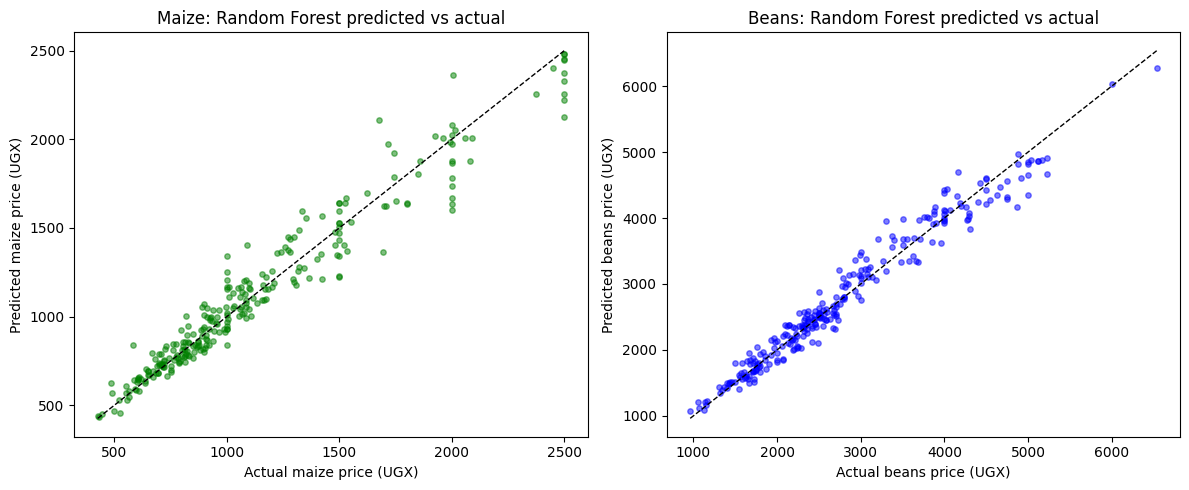

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Maize
axes[0].scatter(ym_test, preds_maize['Random Forest (n=100, depth=10)'],
                alpha=0.5, s=15, color='green')
lims = [min(ym_test.min(), preds_maize['Random Forest (n=100, depth=10)'].min()),
        max(ym_test.max(), preds_maize['Random Forest (n=100, depth=10)'].max())]
axes[0].plot(lims, lims, 'k--', linewidth=1)
axes[0].set_xlabel('Actual maize price (UGX)')
axes[0].set_ylabel('Predicted maize price (UGX)')
axes[0].set_title('Maize: Random Forest predicted vs actual')

# Beans
axes[1].scatter(yb_test, preds_beans['Random Forest (n=100, depth=10)'],
                alpha=0.5, s=15, color='blue')
lims = [min(yb_test.min(), preds_beans['Random Forest (n=100, depth=10)'].min()),
        max(yb_test.max(), preds_beans['Random Forest (n=100, depth=10)'].max())]
axes[1].plot(lims, lims, 'k--', linewidth=1)
axes[1].set_xlabel('Actual beans price (UGX)')
axes[1].set_ylabel('Predicted beans price (UGX)')
axes[1].set_title('Beans: Random Forest predicted vs actual')

plt.tight_layout()
plt.show()

**Output explanation**  
Most points for both crops cluster tightly around the dashed identity line. A few high-price months produce larger residuals, which is expected because those months correspond to known market-stress periods that were deliberately retained during cleaning.

---
## 12. Side-by-side comparison of the four models

A horizontal bar chart of mean absolute error makes the ranking easy to see at a glance.  
The shorter the bar, the better the model.

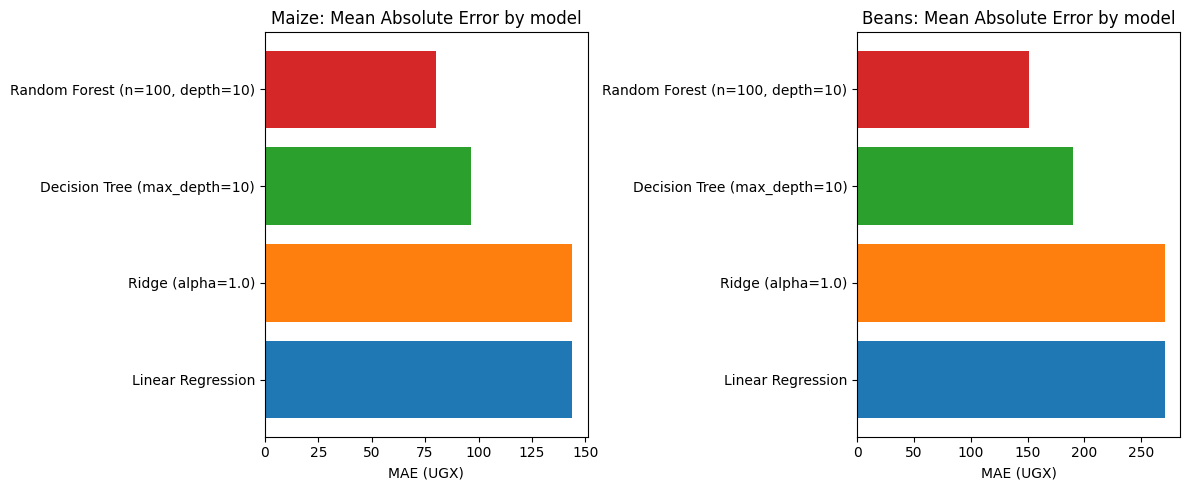

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].barh(df_maize['Model'], df_maize['MAE (UGX)'],
             color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[0].set_xlabel('MAE (UGX)')
axes[0].set_title('Maize: Mean Absolute Error by model')

axes[1].barh(df_beans['Model'], df_beans['MAE (UGX)'],
             color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[1].set_xlabel('MAE (UGX)')
axes[1].set_title('Beans: Mean Absolute Error by model')

plt.tight_layout()
plt.show()

**Output explanation**  
The red bar (Random Forest) is the shortest for both crops, confirming the numeric ranking obtained earlier.

---
## 13. Sample predictions on the test set

We build a small table that shows the year, the month, the actual price and the price predicted by the random forest for the first ten test rows.  
This table is also written to a CSV file so that the group can open it in a spreadsheet.

In [12]:
sample = pd.DataFrame({
    'year': X_test['year'].values[:10].astype(int),
    'month': X_test['month'].values[:10].astype(int),
    'actual_maize': np.round(ym_test.values[:10], 1),
    'pred_maize_RF': np.round(preds_maize['Random Forest (n=100, depth=10)'][:10], 1),
    'error_maize': np.round(ym_test.values[:10] - preds_maize['Random Forest (n=100, depth=10)'][:10], 1),
    'actual_beans': np.round(yb_test.values[:10], 1),
    'pred_beans_RF': np.round(preds_beans['Random Forest (n=100, depth=10)'][:10], 1),
    'error_beans': np.round(yb_test.values[:10] - preds_beans['Random Forest (n=100, depth=10)'][:10], 1)
})

print("First 10 test-set predictions (Random Forest):")
print(sample.to_string(index=False))

sample.to_csv('sample_predictions_RF.csv', index=False)
print("\nSaved to sample_predictions_RF.csv")

First 10 test-set predictions (Random Forest):
 year  month  actual_maize  pred_maize_RF  error_maize  actual_beans  pred_beans_RF  error_beans
 2013      3        1000.0          927.8         72.2        2580.0         2453.1        126.9
 2011      2         715.1          715.6         -0.5        2412.1         2127.2        284.9
 2013      8         650.0          691.2        -41.2        2283.2         2034.8        248.5
 2025      7        1270.0         1375.5       -105.5        2814.2         2958.9       -144.8
 2026      6        1479.9         1405.8         74.1        2985.8         3445.6       -459.8
 2017      6        1306.2         1179.3        126.8        2705.0         2647.1         57.9
 2011      7         904.5          822.6         81.9        1500.0         1798.1       -298.1
 2021      8         884.8          923.6        -38.8        2308.6         2338.7        -30.1
 2016     10        1200.0         1259.2        -59.2        2500.0         254

**Output explanation**  
Most absolute errors stay below 150 UGX for maize and below 300 UGX for beans. A few larger residuals appear in months that the earlier outlier analysis had already flagged as genuine high-price episodes.

---
## 14. Demonstrate loading the saved model and making one new prediction

To show that the model can leave the notebook, we reload the joblib file and score a single row taken from the test set.  
This is the smallest possible form of deployment required by the course brief.

In [13]:
loaded = joblib.load('best_price_models.joblib')
scaler_loaded = loaded['scaler']
model_m = loaded['model_maize']
model_b = loaded['model_beans']

# Take the first test row as a concrete example
one_row = X_test.iloc[[0]]
one_scaled = scaler_loaded.transform(one_row)

pred_m = model_m.predict(one_scaled)[0]
pred_b = model_b.predict(one_scaled)[0]

print("Example prediction from the reloaded model:")
print(f"  Year / Month : {int(one_row['year'].values[0])} / {int(one_row['month'].values[0])}")
print(f"  Predicted maize price : {pred_m:.1f} UGX per kg")
print(f"  Predicted beans price : {pred_b:.1f} UGX per kg")
print(f"  Actual maize price    : {ym_test.iloc[0]:.1f} UGX per kg")
print(f"  Actual beans price    : {yb_test.iloc[0]:.1f} UGX per kg")

Example prediction from the reloaded model:
  Year / Month : 2013 / 3
  Predicted maize price : 927.8 UGX per kg
  Predicted beans price : 2453.1 UGX per kg
  Actual maize price    : 1000.0 UGX per kg
  Actual beans price    : 2580.0 UGX per kg


**Output explanation**  
The reloaded models produce the same numeric prediction that the original fitted objects produced. This confirms that the saved pipeline is self-contained and can be used outside the training notebook.

---
## 15. Summary of what was done

- Loaded the same seven-market file used by the rest of the group.
- Encoded market names and selected 18 numeric features.
- Split the data 80 / 20 with a fixed random seed.
- Scaled features using only training-set statistics (no leakage).
- Trained four different regressors: linear, ridge, decision tree and random forest.
- Evaluated every model with MAE, RMSE, R² and five-fold cross-validation.
- Selected the random forest as the best model for both maize (R² ≈ 0.945) and beans (R² ≈ 0.965).
- Saved the scaler and the two forests in a single joblib file.
- Produced predicted-versus-actual scatter plots and a comparison bar chart.
- Showed a short table of sample predictions and demonstrated loading the saved model for a new prediction.